<a href="https://colab.research.google.com/github/farmanali11/core-ai-learning/blob/main/transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import cv2

import PIL.Image as Image
import os

import matplotlib.pylab as plt

import tensorflow as tf

import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential


In [7]:
IMAGE_SHAPE = (224, 224)

# Load the feature extractor module directly using hub.load
# This returns a callable that can be used like a tf.function
feature_extractor_model = hub.load("https://tfhub.dev/google/imagenet/mobilenet_v2_100_224/feature_vector/5")

inputs = tf.keras.Input(shape=IMAGE_SHAPE + (3,))
# Wrap the loaded feature_extractor_model in a Lambda layer
# The output of the Lambda layer will be the feature vector
x = tf.keras.layers.Lambda(lambda images: feature_extractor_model(images), name='feature_extractor')(inputs)
# Add a dense layer for classification with 1000 classes (ImageNet default)
outputs = tf.keras.layers.Dense(1000, activation='softmax', name='prediction_head')(x)
classifier = tf.keras.Model(inputs=inputs, outputs=outputs)

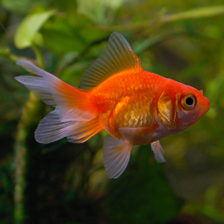

In [8]:
gold_fish = Image.open("goldfish.jpg").resize(IMAGE_SHAPE)

gold_fish

In [9]:
gold_fish = np.array(gold_fish)/255.0
gold_fish.shape

(224, 224, 3)

In [10]:
gold_fish[np.newaxis, ...]

array([[[[0.28235294, 0.33333333, 0.07058824],
         [0.31372549, 0.37254902, 0.09019608],
         [0.34901961, 0.41960784, 0.11764706],
         ...,
         [0.32941176, 0.39215686, 0.00392157],
         [0.32156863, 0.38431373, 0.00392157],
         [0.30980392, 0.36862745, 0.        ]],

        [[0.28627451, 0.33333333, 0.08235294],
         [0.3254902 , 0.38039216, 0.10980392],
         [0.35294118, 0.42352941, 0.12941176],
         ...,
         [0.32156863, 0.38039216, 0.00392157],
         [0.31372549, 0.37254902, 0.00392157],
         [0.30196078, 0.36078431, 0.        ]],

        [[0.28627451, 0.33333333, 0.08627451],
         [0.31372549, 0.36862745, 0.10196078],
         [0.34509804, 0.41568627, 0.12941176],
         ...,
         [0.31764706, 0.37647059, 0.00392157],
         [0.30980392, 0.36862745, 0.00784314],
         [0.29803922, 0.35686275, 0.00392157]],

        ...,

        [[0.05490196, 0.10980392, 0.01568627],
         [0.05098039, 0.11372549, 0.01960784]

In [11]:
result = classifier.predict(gold_fish[np.newaxis, ...])
result.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


(1, 1000)

In [12]:
predicted_label_index = np.argmax(result)
predicted_label_index

np.int64(971)

In [13]:
image_labels = []
with open("ImageNetLabels.txt","r") as f:
  image_labels = f.read().splitlines()

image_labels[:5]

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [14]:
image_labels[predicted_label_index]


'alp'

In [15]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [16]:
data_dir

'./datasets/flower_photos'

In [17]:
import pathlib
data_dir = pathlib.Path(data_dir) / 'flower_photos'
data_dir

PosixPath('datasets/flower_photos/flower_photos')

In [18]:
list(data_dir.glob('*/*.jpg'))[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/2675221506_5286c0595f.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3265902330_d8b1e44545.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3871586333_5a708d5cf4_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4558025386_2c47314528.jpg')]

In [19]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


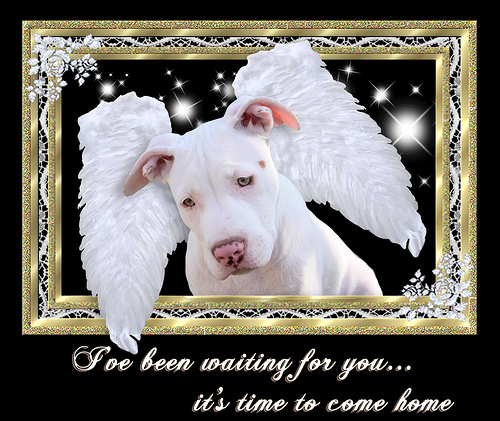

In [21]:
import PIL
roses = list(data_dir.glob('roses/*.jpg'))
PIL.Image.open(str(roses[1]))

In [22]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [23]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [25]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [26]:
cv2.resize(img,(224,224)).shape

(224, 224, 3)

In [27]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(224,224))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [28]:
X = np.array(X)
y = np.array(y)

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [30]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [31]:
IMAGE_SHAPE+(3,)

(224, 224, 3)

In [32]:
x0_resized = cv2.resize(X[0], IMAGE_SHAPE)
x1_resized = cv2.resize(X[1], IMAGE_SHAPE)
x2_resized = cv2.resize(X[2], IMAGE_SHAPE)

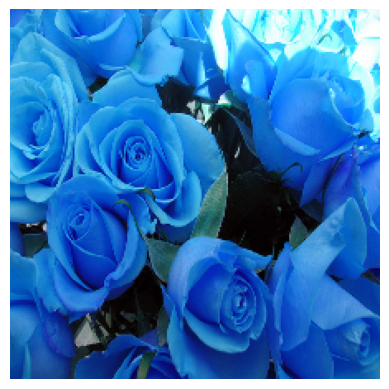

In [33]:
plt.axis('off')
plt.imshow(X[0])

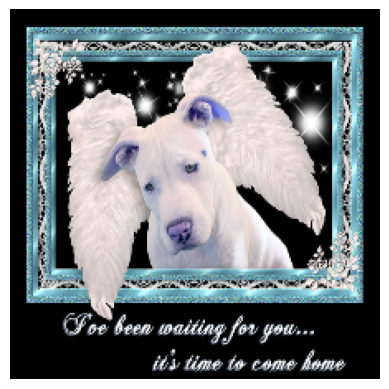

In [34]:
plt.axis('off')
plt.imshow(X[1])

In [35]:
predicted = classifier.predict(np.array([x0_resized, x1_resized, x2_resized]))
predicted = np.argmax(predicted, axis=1)
predicted

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


array([933, 720, 933])

In [36]:
image_labels[795]

'shower curtain'

In [37]:
feature_extractor_url = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

# Load the feature extractor module directly using hub.load
# This returns a callable that can be used like a tf.function
pretrained_model_without_top_layer_callable = hub.load(feature_extractor_url)

# Wrap the loaded callable in a Lambda layer for use in Keras models
# Removed input_shape as it's redundant when the input is already a Keras Tensor
pretrained_model_without_top_layer = tf.keras.layers.Lambda(
    lambda inputs: pretrained_model_without_top_layer_callable(inputs),
    trainable=False # Keep the pre-trained model frozen
)

In [38]:
num_of_flowers = 5

# Use the Keras functional API to build the model
inputs = tf.keras.Input(shape=(224, 224, 3))
x = pretrained_model_without_top_layer(inputs)
outputs = tf.keras.layers.Dense(num_of_flowers)(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,405 (25.02 KB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.compile(
  optimizer="adam",
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['acc'])

model.fit(X_train_scaled, y_train, epochs=5)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - acc: 0.7009 - loss: 0.8003
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - acc: 0.8517 - loss: 0.4250
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - acc: 0.8924 - loss: 0.3320
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - acc: 0.9146 - loss: 0.2781
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - acc: 0.9255 - loss: 0.2403


In [40]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 419ms/step - acc: 0.8834 - loss: 0.3179


[0.317878395318985, 0.8834422826766968]